LOADING THE DATA

In [8]:
#Load libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

In [9]:
#Load the dataset
infile = "https://raw.githubusercontent.com/cgenomicslab/Courses/refs/heads/main/MScNeuro/2026/data/mouse_cognition.csv"

mice = pd.read_csv(infile)

In [10]:
mice.head(10)

,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
0,M001,A,78,72,65,70,8.2,6.5,5.8,7.1,standard,12,yes,12,28.5
1,M002,A,82,75,68,73,8.5,6.8,5.6,7.4,standard,12,yes,14,29.2
2,M003,A,75,70,62,68,7.9,6.3,5.9,6.9,standard,12,no,11,27.8
3,M004,A,80,74,66,71,8.3,6.6,5.7,7.2,enriched,12,yes,13,28.1
4,M005,A,77,71,64,69,8.1,6.4,5.8,7.0,standard,12,no,12,28.9
5,M006,A,83,76,69,74,8.6,6.9,5.5,7.5,enriched,12,yes,15,29.5
6,M007,A,76,69,63,67,7.8,6.2,6.0,6.8,high_fat,12,no,10,30.2
7,M008,A,79,73,65,70,8.2,6.5,5.7,7.1,standard,12,yes,13,28.4
8,M009,A,81,74,67,72,8.4,6.7,5.6,7.3,enriched,12,yes,14,28.8
9,M010,A,74,68,61,66,7.7,6.1,6.1,6.7,high_fat,12,no,11,31.1


Exploring the data

In [13]:
#Summary statistics
mice[['GRIN1', 'social_memory']].describe()


,GRIN1,social_memory
count,120.000000,120.000000
mean,7.153333,70.408333
std,0.842558,8.064338
min,5.500000,55.000000
25%,6.575000,65.000000
50%,7.100000,70.000000
75%,7.625000,75.000000
max,9.100000,91.000000


In [14]:
#Check for missing values
mice[['GRIN1', 'social_memory']].isna().sum()


GRIN1            0
social_memory    0
dtype: int64

Visualization

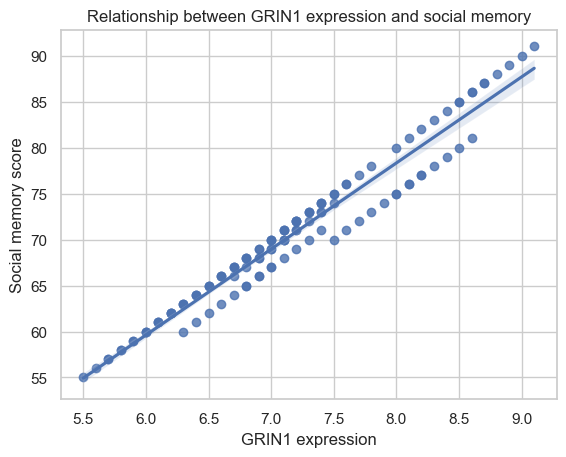

In [ ]:
#Plot the relationship between GRIN1 expression and social memory
#Plot with regression line
sns.regplot(
    data=mice,
    x='GRIN1',
    y='social_memory'
)

plt.xlabel('GRIN1 expression')
plt.ylabel('Social memory score')
plt.title('Relationship between GRIN1 expression and social memory')
plt.show()


Statistical Test

In [17]:
r, p_value = stats.pearsonr(mice['GRIN1'], mice['social_memory'])
print("Correlation (r):", round(r, 3))
print("P-value:", p_value)


Correlation (r): 0.978
P-value: 4.837851033706506e-82


In [ ]:
#Robustness check with Spearman correlation
rho, p_s = stats.spearmanr(mice['GRIN1'], mice['social_memory'])
print(f"Spearman rho = {rho:.3f}, p = {p_s:.4g}")


Spearman rho = 0.982, p = 4.888e-87


Intepretation

### Interpretation

Pearson correlation analysis revealed a very strong positive relationship
between GRIN1 expression and social memory performance (r = 0.978, p < 0.001),
indicating that mice with higher GRIN1 expression tend to show better social
memory scores.

To assess the robustness of this finding, a Spearman rank correlation was
also performed. Spearman analysis confirmed a similarly strong positive
association (ρ = 0.982, p < 0.001), demonstrating that the relationship
remains highly significant when considering rank-based associations and is
not driven by deviations from linearity or by outliers.

Together, these results suggest a robust and biologically meaningful
association between GRIN1 expression and social memory. Given the role of
GRIN1 in NMDA receptor function and synaptic plasticity, higher GRIN1
expression may contribute to neural mechanisms that support social cognitive
performance.
